<a href="https://colab.research.google.com/github/Mudassirsheroz/student-performance-dashboard/blob/main/SE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
import pandas as pd

# Step 1: Upload CSV file
uploaded = files.upload()

# Step 2: Get the filename of the uploaded CSV
csv_filename = list(uploaded.keys())[0]
print(f"Uploaded CSV file: {csv_filename}")

# Step 3: Read CSV directly
df = pd.read_csv(csv_filename)

# Step 4: Show data
print(df.head())


Saving StudentsPerformance.csv to StudentsPerformance (4).csv
Uploaded CSV file: StudentsPerformance (4).csv
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              

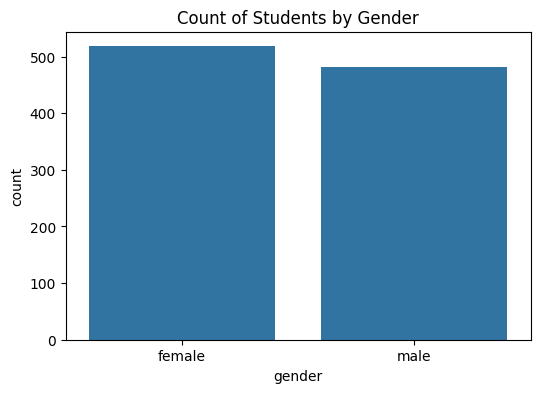

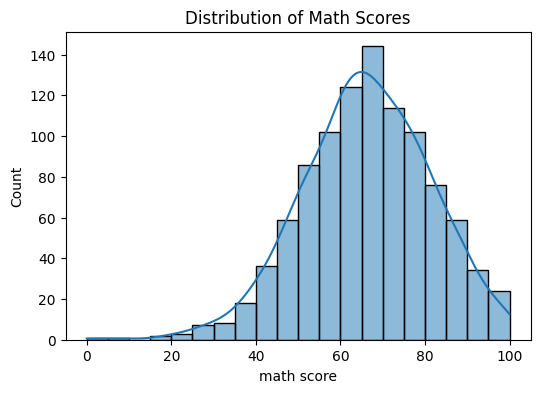


Average Scores by Gender:
        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


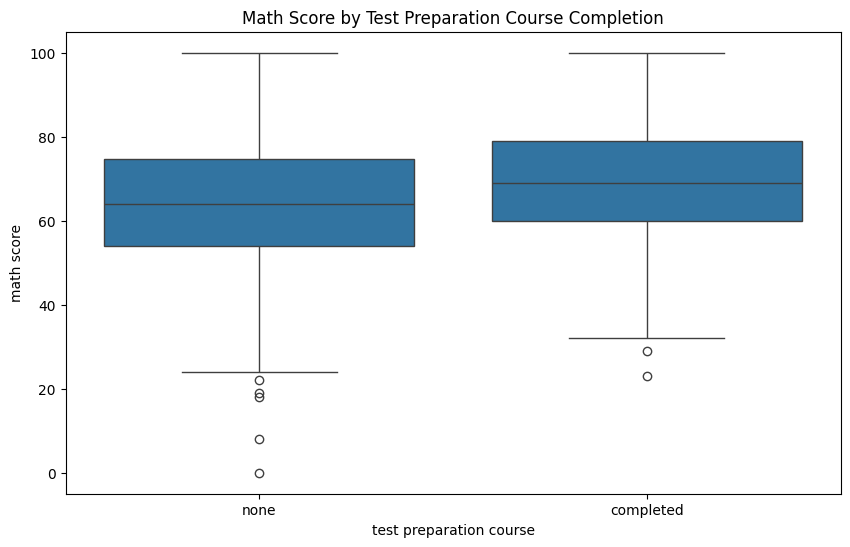

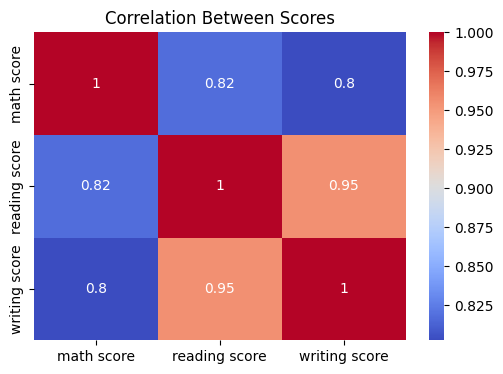


Model Performance:
Mean Squared Error: 77.24
R-squared: 0.68


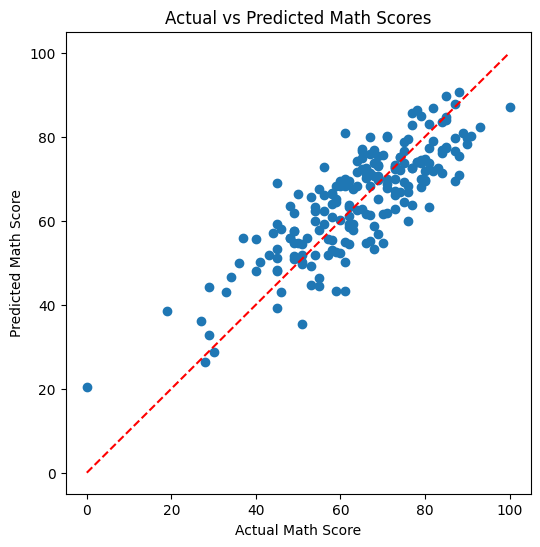

Predictions saved to 'math_score_predictions.csv'


In [8]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('StudentsPerformance (1).csv')

# -----------------------------
# 1. Data Overview
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nCheck for missing values:")
print(df.isnull().sum())

# -----------------------------
# 2. Data Cleaning (if any)
# In this dataset, no missing values; if categorical columns have inconsistent capitalization, fix here:
df['gender'] = df['gender'].str.lower()
df['lunch'] = df['lunch'].str.lower()
df['test preparation course'] = df['test preparation course'].str.lower()

# -----------------------------
# 3. Exploratory Data Analysis (EDA)

# Countplot of gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender')
plt.title('Count of Students by Gender')
plt.show()

# Distribution of math scores
plt.figure(figsize=(6,4))
sns.histplot(df['math score'], kde=True, bins=20)
plt.title('Distribution of Math Scores')
plt.show()

# Average scores by gender
avg_scores_gender = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
print("\nAverage Scores by Gender:")
print(avg_scores_gender)

# Boxplot of scores by test preparation course completion
plt.figure(figsize=(10,6))
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title('Math Score by Test Preparation Course Completion')
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Scores')
plt.show()

# -----------------------------
# 4. Basic Predictive Model
# Goal: Predict math score based on reading and writing scores

# Prepare data
X = df[['reading score', 'writing score']]
y = df['math score']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict math scores on test data
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Plot actual vs predicted math scores
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Scores")
plt.plot([0, 100], [0, 100], color='red', linestyle='--')
plt.show()

# -----------------------------
# 5. Save cleaned data and model predictions

# Add predictions to test data
test_results = X_test.copy()
test_results['Actual Math Score'] = y_test
test_results['Predicted Math Score'] = y_pred

# Save to CSV
test_results.to_csv('math_score_predictions.csv', index=False)
print("Predictions saved to 'math_score_predictions.csv'")


In [ ]:
# Install necessary packages
!pip install dash pyngrok --quiet

# Configure ngrok with your authtoken
!ngrok config add-authtoken 366XHWT6MXYBknSokhG0mAH2QJU_3naKiDpYevsCGWHRDshzm

# Import libraries
from pyngrok import ngrok
import dash
from dash import dcc, html
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv('StudentsPerformance (1).csv')

# Create Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Students Performance Dashboard"),
    dcc.Graph(figure=px.histogram(df, x='gender', color='gender', barmode='group'))
])

# Open tunnel on port 8050
public_url = ngrok.connect(8050)
print(" * Tunnel URL:", public_url)

# Run app on port 8050
app.run(debug=True, port=8050)


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
 * Tunnel URL: NgrokTunnel: "https://lekker-oligotrophic-olimpia.ngrok-free.dev" -> "http://localhost:8050"
Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on


In [ ]:
# ===============================
# Imports
import pandas as pd
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ===============================
# Load data
df = pd.read_csv('StudentsPerformance.csv')

# -------------------------------
# Prepare predictive model
X = df[['reading score', 'writing score']]
y = df['math score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Add predictions to test set
test_results = X_test.copy()
test_results['Actual Math Score'] = y_test
test_results['Predicted Math Score'] = y_pred

# ===============================
# Initialize Dash app
app = dash.Dash(__name__)
app.title = "Students Performance Dashboard"

# ===============================
# Layout
app.layout = html.Div([
    html.H1("Students Performance Dashboard", style={'textAlign': 'center'}),

    # Summary Cards
    html.Div([
        html.Div([
            html.H3("Total Students"),
            html.P(f"{df.shape[0]}")
        ], className='card'),

        html.Div([
            html.H3("Average Math Score"),
            html.P(f"{df['math score'].mean():.2f}")
        ], className='card'),

        html.Div([
            html.H3("Average Reading Score"),
            html.P(f"{df['reading score'].mean():.2f}")
        ], className='card'),

        html.Div([
            html.H3("Average Writing Score"),
            html.P(f"{df['writing score'].mean():.2f}")
        ], className='card'),
    ], style={'display': 'flex', 'justifyContent': 'space-around', 'marginBottom': 30}),

    # Gender Distribution
    html.Div([
        html.H3("Gender Distribution"),
        dcc.Graph(
            figure=px.histogram(df, x='gender', color='gender',
                                title='Count of Students by Gender',
                                barmode='group')
        )
    ]),

    # Score Distribution
    html.Div([
        html.H3("Score Distribution"),
        dcc.Dropdown(
            id='score-dropdown',
            options=[
                {'label': 'Math Score', 'value': 'math score'},
                {'label': 'Reading Score', 'value': 'reading score'},
                {'label': 'Writing Score', 'value': 'writing score'},
            ],
            value='math score',
            clearable=False,
            style={'width': '50%'}
        ),
        dcc.Graph(id='score-histogram')
    ]),

    # Boxplot by Test Preparation
    html.Div([
        html.H3("Scores by Test Preparation Course"),
        dcc.Dropdown(
            id='score-dropdown-box',
            options=[
                {'label': 'Math Score', 'value': 'math score'},
                {'label': 'Reading Score', 'value': 'reading score'},
                {'label': 'Writing Score', 'value': 'writing score'},
            ],
            value='math score',
            clearable=False,
            style={'width': '50%'}
        ),
        dcc.Graph(id='score-boxplot')
    ]),

    # Actual vs Predicted Math Scores
    html.Div([
        html.H3("Actual vs Predicted Math Scores"),
        dcc.Graph(
            figure=px.scatter(test_results, x='Actual Math Score', y='Predicted Math Score',
                              title='Actual vs Predicted Math Scores',
                              labels={'Actual Math Score':'Actual', 'Predicted Math Score':'Predicted'})
        )
    ])
], style={'maxWidth': '900px', 'margin': 'auto'})

# ===============================
# Callbacks
@app.callback(
    Output('score-histogram', 'figure'),
    Input('score-dropdown', 'value')
)
def update_histogram(score_col):
    fig = px.histogram(df, x=score_col, nbins=20, title=f'Distribution of {score_col.title()}')
    fig.update_layout(bargap=0.1)
    return fig

@app.callback(
    Output('score-boxplot', 'figure'),
    Input('score-dropdown-box', 'value')
)
def update_boxplot(score_col):
    fig = px.box(df, x='test preparation course', y=score_col,
                 title=f'{score_col.title()} by Test Preparation Course')
    return fig

# ===============================
# Run server
if __name__ == "__main__":
    app.run(debug=True)
